# day 29 | 251105 W

Today we worked on the shooting method. This is a way of solving differential equations by using the **boundary condition** rather than the **initial conditions**. This method is more difficult to do in terms of computational resources, but method is straightforward. We simply try a bunch of times with different initial conditions until we get really close to the other boundary. It is not very smart, but it is effective and it is easy to code up, because we define a function that solves the differential equation and then we plug that into a root finding algorithm to keep evaluating that function until we find the root. That root means that we hit our target. 

We'll start this today with one dimensional motion, which is a little weird to imagine. We have a ball that we are going to toss straight up into the air. How fast will we need to throw it to land on the ground 10 seconds later. This is a little strange because we normally would want to know how long it takes to come back down given we threw it as hard as we could. Another way that you could frame our current question is, "If I time how long it takes to go up and come down, then how fast did I throw it?" This is what we will work through today.

In [45]:
%matplotlib ipympl

import numpy as np
import matplotlib.pyplot as plt

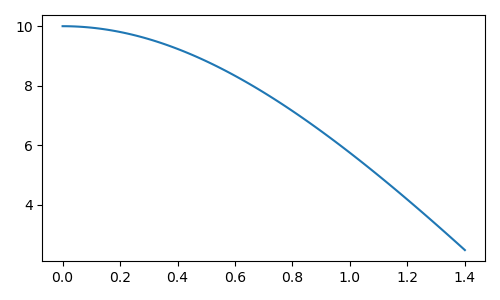

In [110]:
# define the differential equation
def f(r_, t_): # don't forget r is a vector!
    x = r_[0]
    v = r_[1]
    g = 9.8 # N/kg
    m = 1 # kg
    c = 0.1 # what are these units?
    fx = v  # this is the dx/dt equation!
    if v>=0:
        fv = -g - c/m*v**2 # this is the dv/dt equation!
    else: 
        fv = -g + c/m*v**2
    return(np.array([fx, fv]))

# define the boundary condition
a = 0.0
b = 1.414
N = 100
dt = (b-a)/N

# Runge-Kutta 4th order

r = np.array([10.0, 0.0]) # initial condition

tpointsD2 = np.arange(a, b, dt)

xpointsD2 = []
vpointsD2 = []

for i in tpointsD2:
    xpointsD2.append(r[0])
    vpointsD2.append(r[1])
    k1 = dt*f(r, i)
    k2 = dt*f(r+1/2*k1, i+1/2*dt)
    k3 = dt*f(r+1/2*k2, i+1/2*dt)
    k4 = dt*f(r+k3, i+dt)
    r = r + (k1+2*k2+2*k3+k4)/6

fig0, ax0 = plt.subplots(figsize=(5,3))
ax0.plot(tpointsD2, xpointsD2)
fig0.tight_layout()
#ax0.plot(tpoints, xpointsD)
#ax0.plot(tpointsD2, vpointsD2)

In [101]:
g = 9.81
a = 0
b = 10
N = 1000
dt = (b-a)/N
target = 1e-10

def f(r, t):
    x = r[0]
    v = r[1]
    fx = v
    fv = -g 
    return(np.array([fx, fv]))

def h(v_i):
    r = np.array([0.0, v_i]) # initial condition

    tpoints = np.arange(a, b, dt)
    
    #xpoints = []
    #vpoints = []
    
    for i in tpoints:
        #xpoints.append(r[0])
        #vpoints.append(r[1])
        k1 = dt*f(r, i)
        k2 = dt*f(r+1/2*k1, i+1/2*dt)
        k3 = dt*f(r+1/2*k2, i+1/2*dt)
        k4 = dt*f(r+k3, i+dt)
        r = r + (k1+2*k2+2*k3+k4)/6
    return(r)
    

def bisection(function, lower_guess, upper_guess, tolerance=2**-32):
    midpoint = (lower_guess + upper_guess)/2
    n = 0
    while upper_guess - lower_guess > tolerance:
        if function(lower_guess)*function(midpoint)<0:
            upper_guess = midpoint
            midpoint = (lower_guess + upper_guess)/2
        elif function(midpoint)*function(upper_guess)<0:
            lower_guess = midpoint
            midpoint = (lower_guess + upper_guess)/2
        elif function(lower_guess)*function(midpoint)>0 and function(midpoint)*function(upper_guess)>0:
            print('no unique root in that bracket')
            break
        n = n+1
    return(midpoint, n)

def secant(f, guess, delta=1, tolerance = 2**-32):
    x0 = guess
    x1 = x0 + delta
    n = 0
    while abs(f(x1))>tolerance:
        x2 = x1 - (x1-x0)/(f(x1)-f(x0))*f(x1)
        x0 = x1
        x1 = x2
        n += 1
    return(x1, n)

In [90]:
bisection(h, 0.1, 200, target)

(49.05000000001857, 41)

In [91]:
secant(h, 10, 1, target)

(49.05000000000026, 1)

What does this function of \\(h\\) look like? Let's plot it to get a sense of what we are looking at. 

$$\Delta h = v_i + \frac{1}{2} a t^2 $$

which after some rearrangement would make:

$$h_f = (h_i + \frac{1}{2} a t^2) + v_i t $$

and remember that \\(v_i\\) is the variable here and that the time is fixed.  

So that means the y-intercept should be \\(h_i + \frac{1}{2} a t^2\\) which depends on `t` but also the slope should be `t`. And that is what we see!

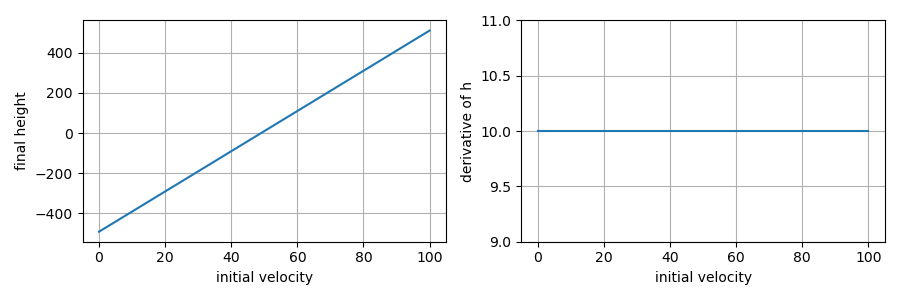

In [99]:
v_initials = np.linspace(0, 100)

h_finals = []

for i in v_initials:
    h_finals.append(h(i))

# just to check, I'll find the derivative of 
# h_finals, which should be TIME
h_prime = np.gradient(h_finals, v_initials)

fig1, [ax1, ax2] = plt.subplots(1,2, figsize=(9,3))
ax1.plot(v_initials, h_finals)
ax2.plot(v_initials, h_prime)
ax1.set_xlabel('initial velocity')
ax1.set_ylabel('final height')
ax2.set_xlabel('initial velocity')
ax2.set_ylabel('derivative of h')
ax2.set_ylim(np.min(h_prime)*0.9, np.max(h_prime)*1.1)
# ax2.yaxis.get_major_formatter().set_scientific(False)
# ax2.yaxis.get_major_formatter().set_useOffset(False)
fig1.tight_layout()
ax1.grid(True)
ax2.grid(True)

Can we do this with the relaxation method? I'm not sure but I'll try to get it to work here. I don't think so, because this means that the function is equal to the variable,  not to zero. And since it is only one function that we want to be equal to zero, there isn't anything else that I can move to the other side of the equal sign. So I'm going with no on this...

In [103]:
v = 50 # initial guess
error = 1 # initial error
count = 0 # counting index to see how many steps
while abs(error)>0.00001:
    r1, v1 = h(v) - v # this doesn't work because v is already close to zero? 
    error = v1 - v
    v = v1
    count = count + 1 
    if count > 1000:
        print('i couldn\'t find an answer so ignore this')
        break
print(v)
print(count)

-98.0999999999924
2
